In [1]:
import numpy as np
import cupy as cp
import matplotlib.pyplot as plt
import drjit as dr
import drjit.nn as dnn
from drjit.opt import Adam, GradScaler
from pathlib import Path
from drjit.cuda.ad import Float32, Float16, TensorXf16, UInt32, Bool
import torch

data = np.load('3D_boxsplines.npy')
data /= data.max()
# weights_path = Path('3D_spline_weights.npz')
weights_path = Path('gpu_3D_spline_weights_drjit.npz')
W = np.load(weights_path)['weights']
print(W.shape)

(1153,)


In [2]:
rng_net = dr.rng(seed=0)

net = dnn.Sequential(
    dnn.Linear(4, 16),
    dnn.ReLU(),
    dnn.Linear(16, 16),
    dnn.ReLU(),
    dnn.Linear(16, 16),
    dnn.ReLU(),
    dnn.Linear(16, 16),
    dnn.ReLU(),
    dnn.Linear(16, 1)
)
net = net.alloc(dtype=TensorXf16, size=4, rng=rng_net)
weights, net = dnn.pack(net, layout='inference')
weights[:] = Float16(W)

Building training grid...


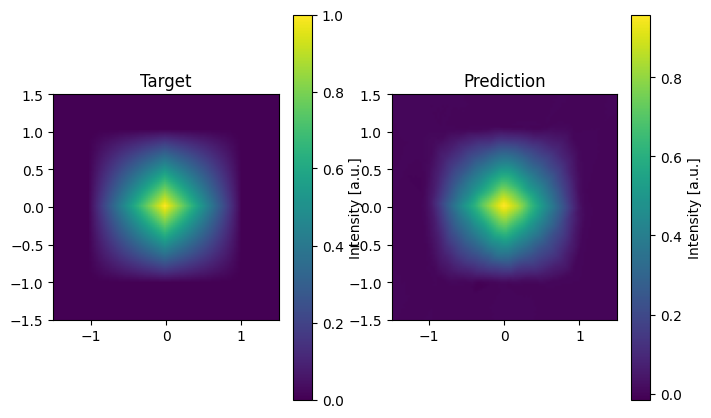

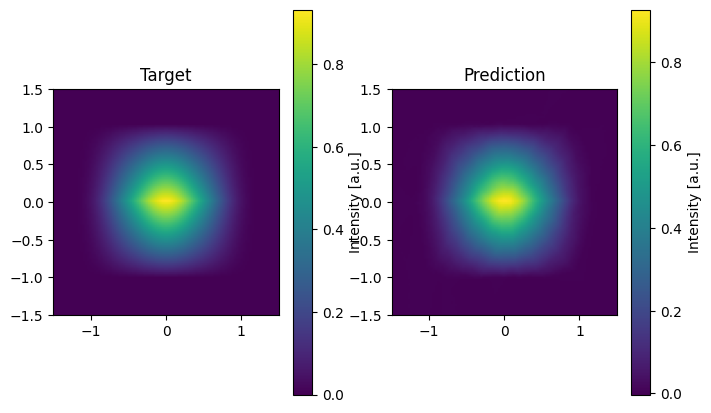

In [3]:
def coop_to_float(cv):
    component, = cv
    return Float(component)

N = 100
L = 1.5
x_values = np.linspace(-L, L, N, dtype=np.float32)
y_values = np.linspace(-L, L, N, dtype=np.float32)
theta_values = np.linspace(0.0, np.pi, N, endpoint=False, dtype=np.float32)

print("Building training grid...")
XX, YY, TT = np.meshgrid(x_values, y_values, theta_values, indexing='ij')
x_flat = XX.ravel()
y_flat = YY.ravel()
theta_flat = TT.ravel()

sin_flat = np.sin(theta_flat).astype(np.float32)
cos_flat = np.cos(theta_flat).astype(np.float32)

def nearest_index(vals, grid):
    step = grid[1] - grid[0]
    return np.clip(np.round((vals - grid[0]) / step).astype(np.int64), 0, len(grid) - 1)

idx_theta = nearest_index(theta_flat, theta_values)
idx_y = nearest_index(y_flat, y_values)
idx_x = nearest_index(x_flat, x_values)
targets_np = data[idx_theta, idx_y, idx_x].astype(np.float32).reshape(-1, 1)

features_np = np.stack([
    x_flat.astype(np.float32),
    y_flat.astype(np.float32),
    sin_flat,
    cos_flat
], axis=1)

num_samples = features_np.shape[0]
train = False  # Set to False to reuse the PyTorch checkpoint instead of training.
torch_weights_path = Path('3D_boxsplines_model.pth')

Float = Float16
FloatAcc = Float32
UInt = dr.uint32_array_t(FloatAcc)

feature_components = [Float(features_np[:, i]) for i in range(features_np.shape[1])]
target_components = Float(targets_np[:, 0])
train_inputs = dnn.CoopVec(*feature_components)
train_targets = target_components
training_volume = targets_np.reshape(N, N, N)

train_prediction = coop_to_float(net(train_inputs))
train_prediction_np = np.array(dr.detach(train_prediction)).reshape(N, N, N)

plt.figure(figsize=(8, 5))
plt.subplot(1, 2, 1)
plt.title('Target')
plt.imshow(training_volume[:, :, 0], extent=(-L, L, -L, L))
plt.colorbar(label='Intensity [a.u.]')
plt.subplot(1, 2, 2)
plt.title('Prediction')
plt.imshow(train_prediction_np[:, :, 0], extent=(-L, L, -L, L))
plt.colorbar(label='Intensity [a.u.]')
plt.show()

plt.figure(figsize=(8, 5))
plt.subplot(1, 2, 1)
plt.title('Target')
plt.imshow(training_volume[:, :, 12], extent=(-L, L, -L, L))
plt.colorbar(label='Intensity [a.u.]')
plt.subplot(1, 2, 2)
plt.title('Prediction')
plt.imshow(train_prediction_np[:, :, 12], extent=(-L, L, -L, L))
plt.colorbar(label='Intensity [a.u.]')
plt.show()


In [4]:
# Float = Float16
# rng_net = dr.rng(seed=5)

# net = dnn.Sequential(
#     dnn.Linear(4, 16),
#     dnn.ReLU(),
#     dnn.Linear(16, 16),
#     dnn.ReLU(),
#     dnn.Linear(16, 16),
#     dnn.ReLU(),
#     dnn.Linear(16, 16),
#     dnn.ReLU(),
#     dnn.Linear(16, 1)
# )
# net = net.alloc(dtype=TensorXf16, size=4, rng=rng_net)

# class TorchSplineNN(torch.nn.Module):
#     def __init__(self):
#         super().__init__()
#         self.fc1 = torch.nn.Linear(4, 16)
#         self.fc2 = torch.nn.Linear(16, 16)
#         self.fc3 = torch.nn.Linear(16, 16)
#         self.fc4 = torch.nn.Linear(16, 16)
#         self.fc5 = torch.nn.Linear(16, 1)

#     def forward(self, x):
#         x = torch.relu(self.fc1(x))
#         x = torch.relu(self.fc2(x))
#         x = torch.relu(self.fc3(x))
#         x = torch.relu(self.fc4(x))
#         return self.fc5(x)

# torch_model = TorchSplineNN()
# state_dict = torch.load('3D_boxsplines_model.pth', map_location='cpu')
# torch_model.load_state_dict(state_dict)

# torch_layers = [module for module in torch_model.modules() if isinstance(module, torch.nn.Linear)]
# dr_layers = [layer for layer in net.layers if isinstance(layer, dnn.Linear)]
# if len(torch_layers) != len(dr_layers):
#     raise RuntimeError('Mismatched layer counts between PyTorch and Dr.Jit models.')

# for torch_layer, dr_layer in zip(torch_layers, dr_layers):
#     weight_np = torch_layer.weight.detach().cpu().numpy().astype(np.float32)
#     bias_np = torch_layer.bias.detach().cpu().numpy().astype(np.float32)
#     dr_layer.weights[:] = TensorXf16(weight_np)
#     dr_layer.bias[:] = TensorXf16(bias_np)

# weights, net = dnn.pack(net, layout='training')
# print(f'Loaded weights from PyTorch checkpoint; buffer shape: {weights.shape}')
# np.savez_compressed('3D_spline_weights.npz', weights=weights)